In [3]:
import pandas as pd
import seaborn as sns
import numpy as np


In [6]:
np.random.seed(42)
date=pd.date_range(start="2022-01-01",periods=200,freq="D")
trend=np.linspace(100,200,200)
seasonality=10*np.sin(np.linspace(0,20,200))
noise=np.random.normal(0,5,200)

sales=trend+seasonality+noise

df=pd.DataFrame({'date':date,"sales":sales})

df.set_index('date',inplace=True)

In [7]:
df.head()

,sales
date,
2022-01-01,102.483571
2022-01-02,100.814525
2022-01-03,106.240010
2022-01-04,112.092288
2022-01-05,104.751973


In [8]:
df.shape

(200, 1)

In [12]:
!pip install statsmodels


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 294.2 kB/s eta 0:00:31
   -- ------------------------------------- 0.5/9.6 MB 294.2 kB/s eta 0:00:31
   -- ------------------------------------- 0.5/9.6 MB 294.2 kB/s eta 0:00:31
   --- ------------------------------------ 0.8/9.6 MB 376.9 kB/s eta 0:00:24
   --- ------------------------------------ 0.8/9.6 MB 376.9 kB/s eta 0:00:24
   --- ------------------------------------ 0.8/9.6 MB 376


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\CM617YH\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(df['sales'],model="additive",period=30)

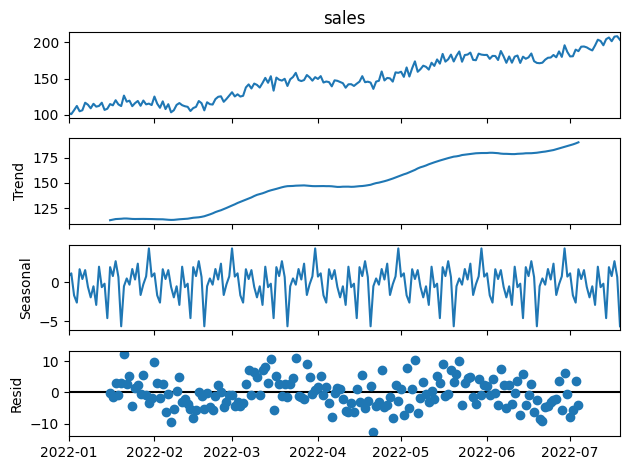

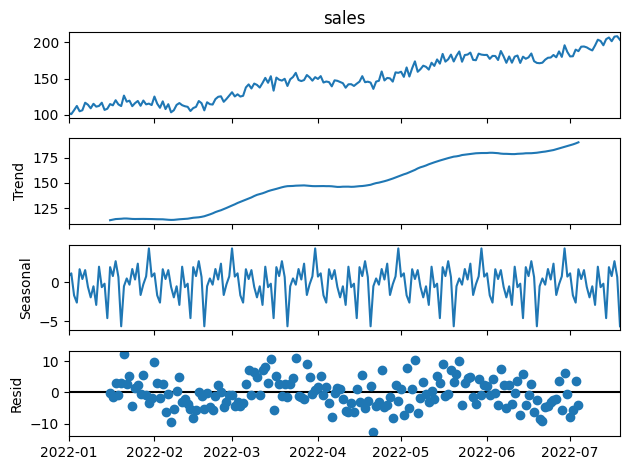

In [15]:
result.plot()

In [16]:
from statsmodels.tsa.stattools import adfuller

result=adfuller(df['sales'])

print("Adf statistics :",result[0])
print("pvalue:",result[1])

Adf statistics : 0.22751963985812654
pvalue: 0.973763530015474


In [17]:
df["diff"]=df["sales"].diff()
df=df.dropna()

In [21]:
result=adfuller(df['diff'])

print("Adf statistics :",result[0])
print("pvalue:",result[1])

Adf statistics : -11.509757909461591
pvalue: 4.288291613005001e-21


In [19]:
df['log']=np.log(df['sales'])

In [20]:
df.head()

,sales,diff,log
date,,,
2022-01-02,100.814525,-1.669046,4.613282
2022-01-03,106.240010,5.425485,4.665701
2022-01-04,112.092288,5.852278,4.719323
2022-01-05,104.751973,-7.340315,4.651595
2022-01-06,106.158168,1.406195,4.664930


In [22]:
result=adfuller(df['log'])

print("Adf statistics :",result[0])
print("pvalue:",result[1])

Adf statistics : -0.4864538482107477
pvalue: 0.8946329393096566


In [24]:
from statsmodels.tsa.ar_model import AutoReg

model=AutoReg(df['sales'],lags=2)
model_fit=model.fit()

model_fit.summary()

C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                  sales   No. Observations:                  199
Model:                     AutoReg(2)   Log Likelihood                -629.535
Method:               Conditional MLE   S.D. of innovations              5.910
Date:                Fri, 17 Apr 2026   AIC                           1267.070
Time:                        08:14:42   BIC                           1280.203
Sample:                    01-04-2022   HQIC                          1272.386
                         - 07-19-2022                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2990      2.243      1.025      0.305      -2.097       6.695
sales.L1       0.5048      0.062      8.093      0.000       0.383       0.627
sales.L2       0.4849      0.063      7.750      0.000       0.362       0.608
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.0069           +0.0000j            1.0069            0.0000
AR.2           -2.0480           +0.0000j            2.0480            0.5000
-----------------------------------------------------------------------------
"""

In [25]:
forecast=model_fit.forecast(steps=10)

print(forecast)


2022-07-20    206.076669
2022-07-21    204.972744
2022-07-22    205.706342
2022-07-23    205.541368
2022-07-24    205.813821
2022-07-25    205.871364
2022-07-26    206.032532
2022-07-27    206.141798
2022-07-28    206.275113
2022-07-29    206.395399
Freq: D, dtype: float64


C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [28]:
from statsmodels.tsa.arima.model import ARIMA

model=ARIMA(df['sales'],order=(1,1,1))
model_fit=model.fit()

model_fit.summary()

C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  199
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -623.692
Date:                Fri, 17 Apr 2026   AIC                           1253.383
Time:                        08:19:32   BIC                           1263.248
Sample:                    01-02-2022   HQIC                          1257.376
                         - 07-19-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1364      0.119     -1.148      0.251      -0.369       0.096
ma.L1         -0.5316      0.106     -4.993      0.000      -0.740      -0.323
sigma2        31.8023      3.469      9.166      0.000      25.002      38.602
===================================================================================
Ljung-Box (L1) (Q):                   0.69   Jarque-Bera (JB):                 0.77
Prob(Q):                              0.41   Prob(JB):                         0.68
Heteroskedasticity (H):               1.02   Skew:                             0.03
Prob(H) (two-sided):                  0.93   Kurtosis:                         2.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
forecast=model_fit.forecast(steps=10)
print(forecast)

2022-07-20    205.602584
2022-07-21    205.304205
2022-07-22    205.344895
2022-07-23    205.339346
2022-07-24    205.340103
2022-07-25    205.340000
2022-07-26    205.340014
2022-07-27    205.340012
2022-07-28    205.340012
2022-07-29    205.340012
Freq: D, Name: predicted_mean, dtype: float64


In [30]:
forecast=model_fit.get_forecast(steps=10)
conf_int=forecast.conf_int()

In [31]:
conf_int

,lower sales,upper sales
2022-07-20,194.549664,216.655504
2022-07-21,193.657950,216.950460
2022-07-22,192.794710,217.895081
2022-07-23,191.993424,218.685269
2022-07-24,191.237250,219.442957
2022-07-25,190.519607,220.160392
2022-07-26,189.835151,220.844877
2022-07-27,189.179657,221.500367
2022-07-28,188.549734,222.130290
2022-07-29,187.942605,222.737420


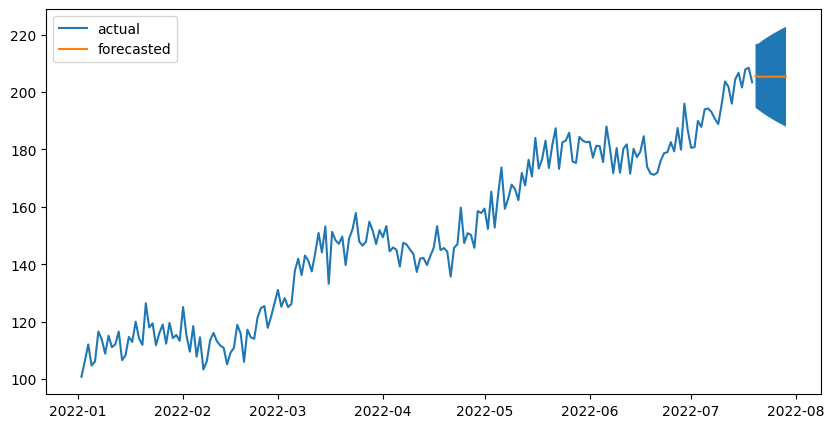

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['sales'],label='actual')
plt.plot(forecast.predicted_mean,label='forecasted')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 )

plt.legend()
plt.show()
